In [177]:
import numpy as np
from matplotlib import pyplot as plt
import csv

# %matplotlib inline
import xarray as xr
import lib_ecofun as lef

from scipy.optimize import curve_fit, minimize, dual_annealing, basinhopping, brute, differential_evolution, shgo

# %%
from importlib import reload
import os
import sys
import pickle

gdp2 = lef.read_gdp_owid()

#tag = 'gdp_noinfl_1804_ext/'
#ok_gdp = gdp2.sel(year = slice(2000, None))
#gdp_fit = ok_gdp # xr.DataArray(spezzata, coords={"year": ok_gdp.year}, dims="year")

#tag = 'gdp_current_1804_ext/'
tag = 'gdp_current_1804_wI_dynprice'
# tag = 'gdp_current_1804'
ok_gdp = lef.gdp.sel(year = slice(2000, None))
gdp_fit = ok_gdp # xr.DataArray(spezzata, coords={"year": ok_gdp.year}, dims="year")

do_dualfit = False
do_diffevofit = False
compute = True # runs the model on the best fits for plotting. !!! FALSE DOES NOT WORK -> random pick with no seed
###############################################################################################

# %%
cart_figs = tag + '/'
if not os.path.exists(cart_figs): os.mkdir(cart_figs)

In [158]:
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

In [178]:
if not do_dualfit:
    print('Reading fit result...')
    params_fit, inicond_recalc = lef.parse_parameter_file(cart_figs + 'final_results_dual.log')
    print("Params:", params_fit)
    print("Inicond:", inicond_recalc)

Reading fit result...
Params: {'growth': 0.01, 'eps': 0.2944960436528168, 'a': 1.0278425013338848, 'b': 1.2, 'gamma_f': 0.1610311827153511, 'gamma_g': 0.1610311827153511, 'eta_g': 0.28667051319819253, 'eta_f': 0.28667051319819253, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.31678118141340417, 'beta_0': 0.07475812532597267, 'delta_sig': 0.5045782500694121, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015, 'alpha_util': 1.5}
Inicond: {'Y_ini': 1.0, 'Eg_ini': 0.07825325742181562, 'Ef_ini': 0.9217467425781845, 'E_ini': 1.0, 'Kf_ini': 0.9601528568522755, 'Kg_ini': 0.07613351006624292}


In [180]:
rainbow_palette_5 = [
    "#D70000",  # Dark Red
    "#FFC700",  # Gold
    "#008700",  # Dark Green
    "#0057A0",  # Dark Blue
    "#7B1FA2"  # deep purple
]

rainbow_palette_10 = [
    "#C0001A",  # deep red
    "#E84B1A",  # vermillion
    "#E87E00",  # burnt orange
    "#C8A800",  # golden yellow
    "#5A9E00",  # olive green
    "#00893E",  # forest green
    "#007A8C",  # teal
    "#0057B8",  # cobalt blue
    "#3D2FBF",  # indigo
    "#7B1FA2",  # deep purple
]

rainbow_palette_9 = [
    "#C0001A",  # deep red
    "#E84B1A",  # vermillion
    "#E87E00",  # burnt orange
    "#C8A800",  # golden yellow
    "#00893E",  # forest green
    "#007A8C",  # teal
    "#0057B8",  # cobalt blue
    "#3D2FBF",  # indigo
    "#7B1FA2",  # deep purple
]

###############################################33

# %%
allobs = lef.define_obs(None, adimensional=True)
allobs_dim = lef.define_obs(None, adimensional=False)

year_ini = 2000
verbose = False
public_investment = False
#params_fit['r_inv_state'] = 0.015
arr = np.concatenate([np.linspace(0., 0.7, 20), np.linspace(0.7, 0.7, 80)])
mu_scen = xr.DataArray(arr, dims = ('year'), coords = {'year': np.arange(year_ini, year_ini + 100)})

scale_costs = True
same_price = True
recalc_inicond = True


In [181]:
obs2 = lef.define_obs(['E', 'Eg_ratio', 'Ig_ratio', 'I'], year_ref = year_ini)
obs_weights2 = {'E': 1, 'Eg_ratio': 10, 'Ig_ratio': 1, 'I': 1}

In [182]:
# params_fit['delta_f'] = 0.005
# params_fit['delta_g'] = 0.005
params_fit['delta_f'] = 0.01
params_fit['delta_g'] = 0.01

params_fit['alpha_util'] = 1.5
dynamic_price = True
energy_crisis_mode = True

0.0
params:  {'growth': 0.01, 'eps': 0.2944960436528168, 'a': 1.0278425013338848, 'b': 1.2, 'gamma_f': 0.1610311827153511, 'gamma_g': 0.1610311827153511, 'eta_g': 0.28667051319819253, 'eta_f': 0.28667051319819253, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.31678118141340417, 'beta_0': 0.07475812532597267, 'delta_sig': 0.5045782500694121, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015, 'alpha_util': 1.5}
check:       0.10     -0.74      0.08      0.92      0.00      0.10      0.00      0.03
params:  {'growth': 0.01, 'eps': 0.2944960436528168, 'a': 1.0278425013338848, 'b': 1.2, 'gamma_f': 0.1610311827153511, 'gamma_g': 0.1610311827153511, 'eta_g': 0.28667051319819253, 'eta_f': 0.28667051319819253, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.31678118141340417, 'beta_0': 0.07475812532597267, 'delta_sig': 0.5045782500694121, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015, 'alpha_util': 1.5}
check:       0.10     -0.73      0.08      0.92      0.00      0.10   

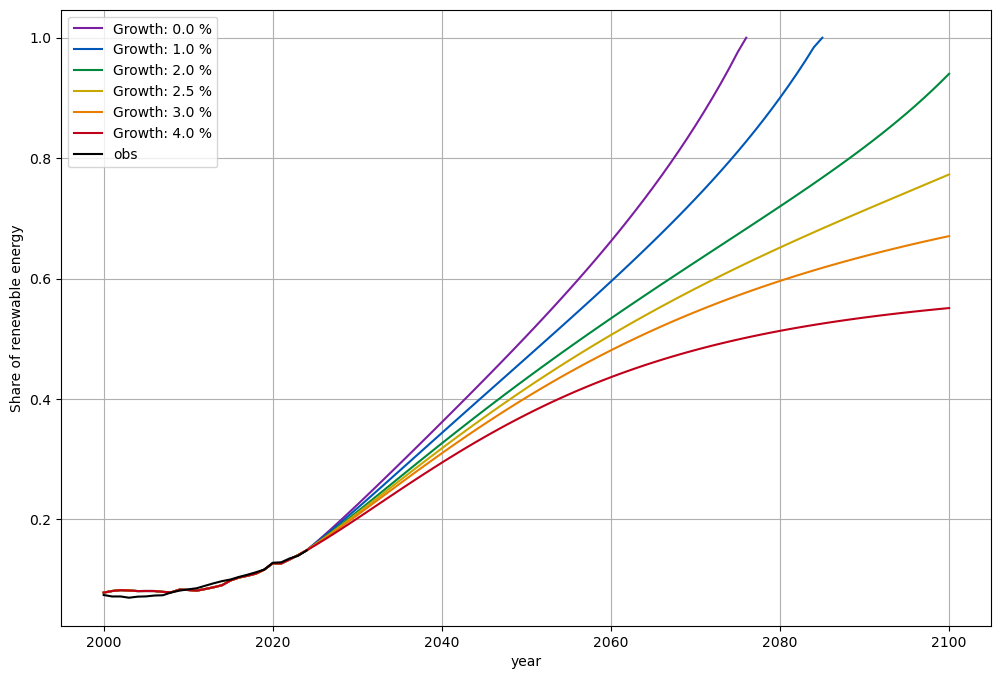

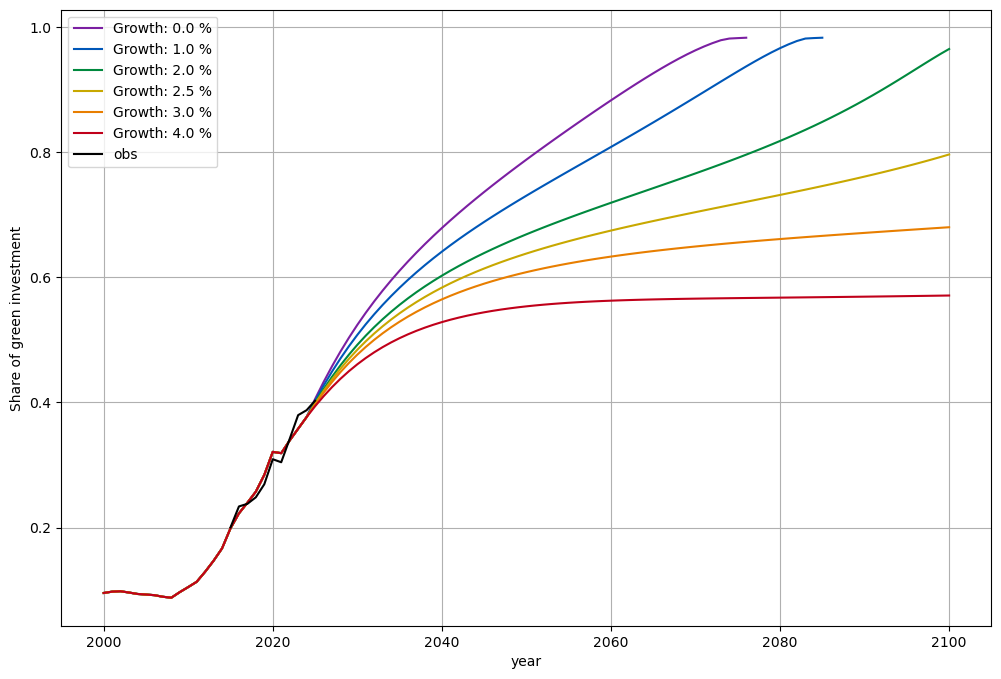

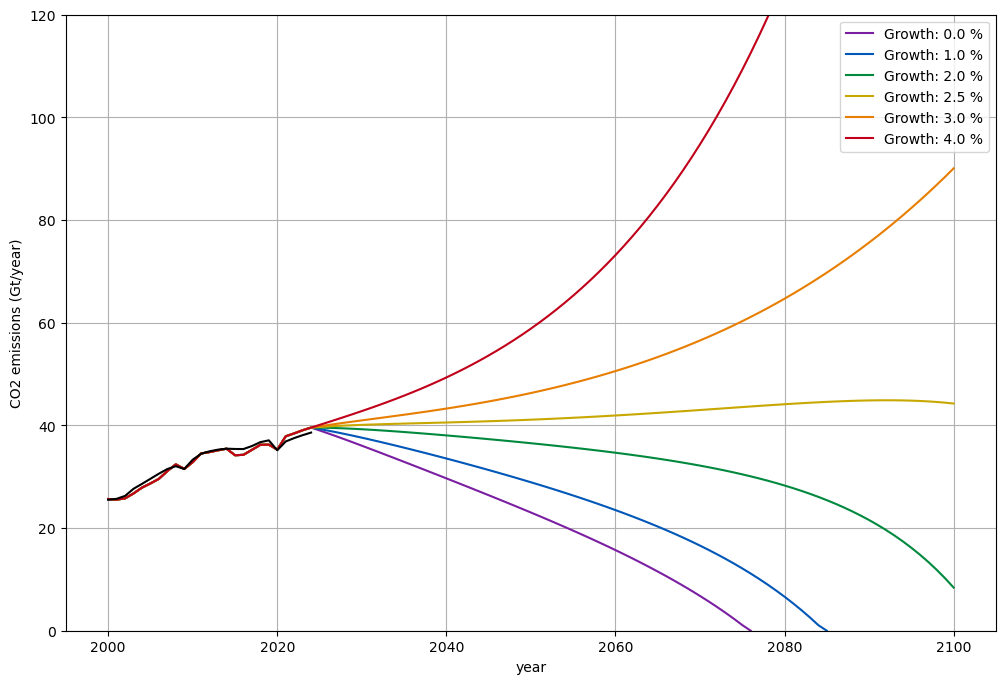

In [183]:
all_growths = dict()

for gro in np.arange(0., 0.055, 0.005):
    gdp_gro = []
    Y0 = gdp_fit.sel(year = 2024).values + 0.
    for i in range(2102-2025):
        Y1 = lef.GDP(Y0, growth= gro)
        gdp_gro.append(Y1)
        Y0 = Y1 + 0.

    ds = xr.DataArray(gdp_gro, coords={'year': np.arange(2025, 2102)})

    gdp_fin = xr.concat([gdp_fit, ds], dim = 'year')

    all_growths[gro] = gdp_fin

# %%
resu_groscen = []
for gro in np.arange(0., 0.055, 0.005):
    print(gro)
    scen = all_growths[gro]/all_growths[gro].sel(year = 2000)
    resuok = lef.run_model(inicond = inicond_recalc, params = params_fit, n_iter = 101, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=scale_costs, gdp_type='custom', gdp_scenario=scen, energy_crisis_mode = energy_crisis_mode, dynamic_price = dynamic_price, same_price=True)
    resu_groscen.append(resuok)

do_all = [1, 0, 1, 0, 1, 1, 1, 0, 1]

fig = plt.figure(figsize = (12, 8))

for gro, re, col, do in zip(np.arange(0., 0.055, 0.005), resu_groscen, rainbow_palette_9[::-1], do_all):
    if do: re['Eg_ratio'].plot(label = f'Growth: {int(1000*gro)/10} %', color = col)

lef.Eg_ratio.sel(year = slice(2000, None)).plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('Share of renewable energy')
plt.legend()
plt.grid()

fig.savefig(cart_figs + 'resu_groscen_Egratio_dynprice.pdf')

# %%
fig = plt.figure(figsize = (12, 8))

for gro, re, col, do in zip(np.arange(0., 0.055, 0.005), resu_groscen, rainbow_palette_9[::-1], do_all):
    if do: re['Ig_ratio'].plot(label = f'Growth: {int(1000*gro)/10} %', color = col)

obs2['Ig_ratio'].sel(year = slice(2000, None)).plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('Share of green investment')
plt.legend()
plt.grid()

fig.savefig(cart_figs + 'resu_groscen_Igratio_dynprice.pdf')

# %%
emiss_scen = dict()

# %%
fig = plt.figure(figsize = (12, 8))

for gro, re, col, do in zip(np.arange(0., 0.055, 0.005), resu_groscen, rainbow_palette_9[::-1], do_all):
    if do: 
        lef.to_emissions(re['Ef']).plot(label = f'Growth: {int(1000*gro)/10} %', color = col)
        emiss_scen[gro] = lef.to_emissions(re['Ef'])

# lef.to_emissions(resu_hist['Ef']).sel(year = slice(2000, 2023)).plot(color = 'grey')
lef.co2.sel(year = slice(2000, None)).plot(color = 'black')
# lef.Eg_ratio.plot(label = 'obs', color = 'black')
plt.ylim(0., 120.)

plt.xlabel('year')
plt.ylabel('CO2 emissions (Gt/year)')
plt.legend()
plt.grid()

fig.savefig(cart_figs + 'resu_groscen_CO2emiss_dynprice.pdf')



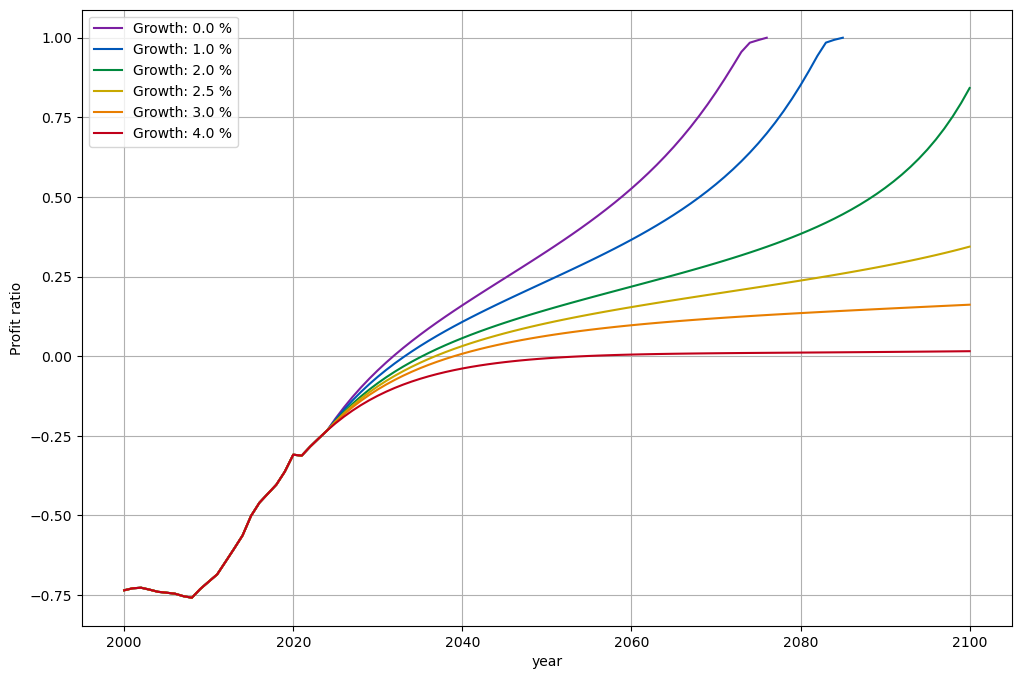

In [184]:
fig = plt.figure(figsize = (12, 8))

for gro, re, col, do in zip(np.arange(0., 0.055, 0.005), resu_groscen, rainbow_palette_9[::-1], do_all):
    if do: 
        lef.prof_ratio(re['Pg'], re['Pf'], re['Kg'], re['Kf']).plot(label = f'Growth: {int(1000*gro)/10} %', color = col)
        # re['Pg'].plot(label = f'Growth: {int(1000*gro)/10} %', color = col, ls = '--')
        
# lef.to_emissions(resu_hist['Ef']).sel(year = slice(2000, 2023)).plot(color = 'grey')
# lef.Eg_ratio.plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('Profit ratio')
plt.legend()
plt.grid()

fig.savefig(cart_figs + 'resu_groscen_profits_dynprice.pdf')

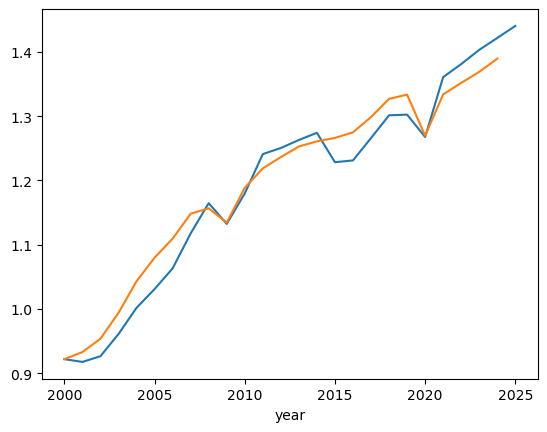

In [185]:
re['Ef'].sel(year = slice(2000, 2025)).plot()
allobs['Ef'].sel(year = slice(2000, 2025)).plot()

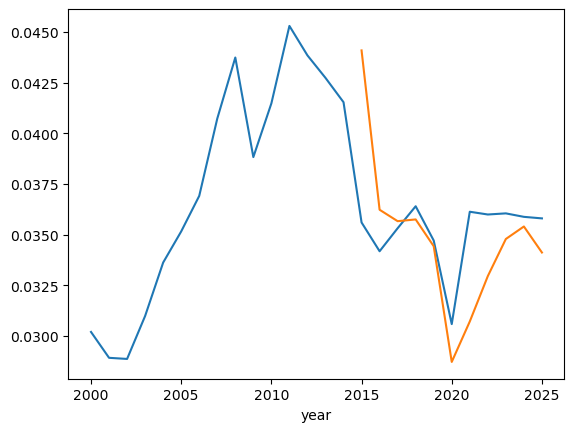

In [186]:
re['If'].sel(year = slice(2000, 2025)).plot()
allobs['If'].sel(year = slice(2000, 2025)).plot()

In [187]:
print(params_fit['a'])
a_val = 0.5

delta_K_obs = (allobs['Ef'].sel(year = 2024) - allobs['Ef'].sel(year = 2015))/a_val

delta_estim = (delta_K_obs -allobs['If'].sel(year = slice(2015, 2024)).sum())/re['Kf'].sel(year = slice(2015, 2024)).sum()
print(delta_estim)

1.0278425013338848
<xarray.DataArray ()>
array(-0.00703398)


In [188]:
deltaE = (allobs['Ef'].sel(year = 2024) - allobs['Ef'].sel(year = 2015))
E0 = allobs['Ef'].sel(year = 2015)
n = 10
I_tot = allobs['If'].sel(year = slice(2015, 2024)).sum()
fut = 0.8

for delta in [0., 0.005, 0.01, 0.015]:
    a_estim = (deltaE * (1 + delta*n/2) + delta*n*E0)/(fut * I_tot)
    a_estim_abs = a_estim * allobs_dim['E'].sel(year = 2000)/allobs_dim['Y'].sel(year = 2000)
    print(f'delta {delta}   ->   adim: {a_estim.values:6.2f} - dim: {a_estim_abs.values:6.2f}')

delta 0.0   ->   adim:   0.44 - dim:   1.34
delta 0.005   ->   adim:   0.68 - dim:   2.06
delta 0.01   ->   adim:   0.92 - dim:   2.78
delta 0.015   ->   adim:   1.16 - dim:   3.50


In [189]:
deltaE = (allobs['Eg'].sel(year = 2024) - allobs['Eg'].sel(year = 2015))
E0 = allobs['Eg'].sel(year = 2015)
n = 10
I_tot = allobs['Ig'].sel(year = slice(2015, 2024)).sum()
fut = 1.

for delta in [0., 0.005, 0.01, 0.015]:
    a_estim = (deltaE * (1 + delta*n/2) + delta*n*E0)/(fut * I_tot)
    a_estim_abs = a_estim * allobs_dim['E'].sel(year = 2000)/allobs_dim['Y'].sel(year = 2000)
    print(f'delta {delta}   ->   adim: {a_estim.values:6.2f} - dim: {a_estim_abs.values:6.2f}')

delta 0.0   ->   adim:   0.70 - dim:   2.11
delta 0.005   ->   adim:   0.76 - dim:   2.31
delta 0.01   ->   adim:   0.83 - dim:   2.51
delta 0.015   ->   adim:   0.89 - dim:   2.71


In [190]:
lef.co2.sel(year = 2023)

<xarray.DataArray 'co2' ()>
array(38.094039)
Coordinates:
    year     float64 2.023e+03

In [191]:
(0.5/0.8)**1.2

0.5689263134456501

In [192]:
allobs['Ef'].sel(year = 2023)

<xarray.DataArray ()>
array(1.36903889)
Coordinates:
    year     int64 2023

### Testing energy crisis instead than stop

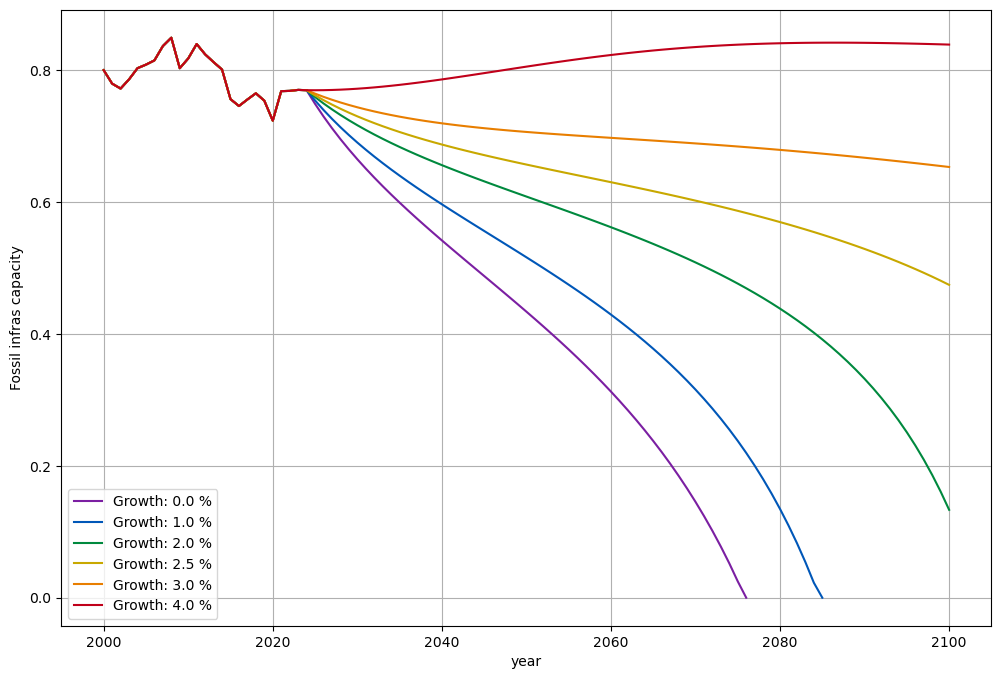

In [193]:
fig = plt.figure(figsize = (12, 8))

for gro, re, col, do in zip(np.arange(0., 0.055, 0.005), resu_groscen, rainbow_palette_9[::-1], do_all):
    if do: 
        fossil_cap = re['Ef']/(params_fit['b']*re['Kf'])
        fossil_cap.plot(label = f'Growth: {int(1000*gro)/10} %', color = col)

plt.xlabel('year')
plt.ylabel('Fossil infras capacity')
plt.legend()
plt.grid()

(2020.0, 2100.0)

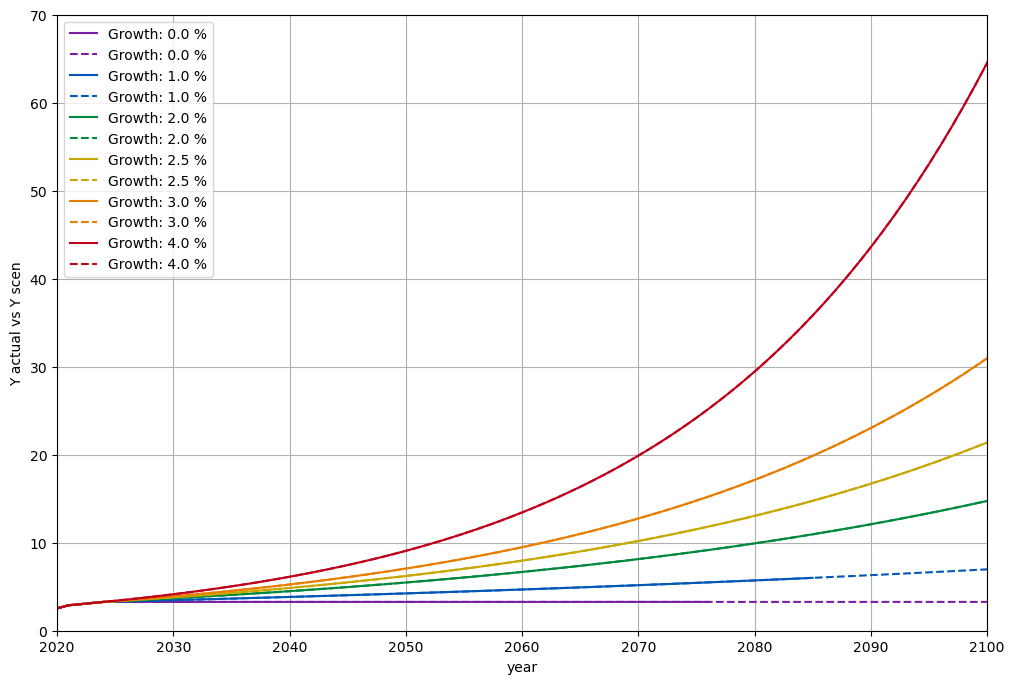

In [194]:
fig = plt.figure(figsize = (12, 8))

for gro, re, col, do in zip(np.arange(0., 0.055, 0.005), resu_groscen, rainbow_palette_9[::-1], do_all):
    if do: 
        re['Y'].plot(label = f'Growth: {int(1000*gro)/10} %', color = col)
        scen = all_growths[gro]/all_growths[gro].sel(year = 2000)
        scen.plot(label = f'Growth: {int(1000*gro)/10} %', color = col, ls = '--')

plt.xlabel('year')
plt.ylabel('Y actual vs Y scen')
plt.legend()
plt.grid()

plt.ylim(0, 70)
plt.xlim(2020, 2100)

### Sensitivity to minimum price assumption

In [195]:
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

0.0
params:  {'growth': 0.01, 'eps': 0.2944960436528168, 'a': 1.0278425013338848, 'b': 1.2, 'gamma_f': 0.1610311827153511, 'gamma_g': 0.1610311827153511, 'eta_g': 0.28667051319819253, 'eta_f': 0.28667051319819253, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.31678118141340417, 'beta_0': 0.07475812532597267, 'delta_sig': 0.5045782500694121, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015, 'alpha_util': 1.5, 'min_price': 1.0}
check:       0.10     -0.74      0.08      0.92      0.00      0.10      0.00      0.03
params:  {'growth': 0.01, 'eps': 0.2944960436528168, 'a': 1.0278425013338848, 'b': 1.2, 'gamma_f': 0.1610311827153511, 'gamma_g': 0.1610311827153511, 'eta_g': 0.28667051319819253, 'eta_f': 0.28667051319819253, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.31678118141340417, 'beta_0': 0.07475812532597267, 'delta_sig': 0.5045782500694121, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015, 'alpha_util': 1.5, 'min_price': 1.0}
check:       0.10     -0.73      0

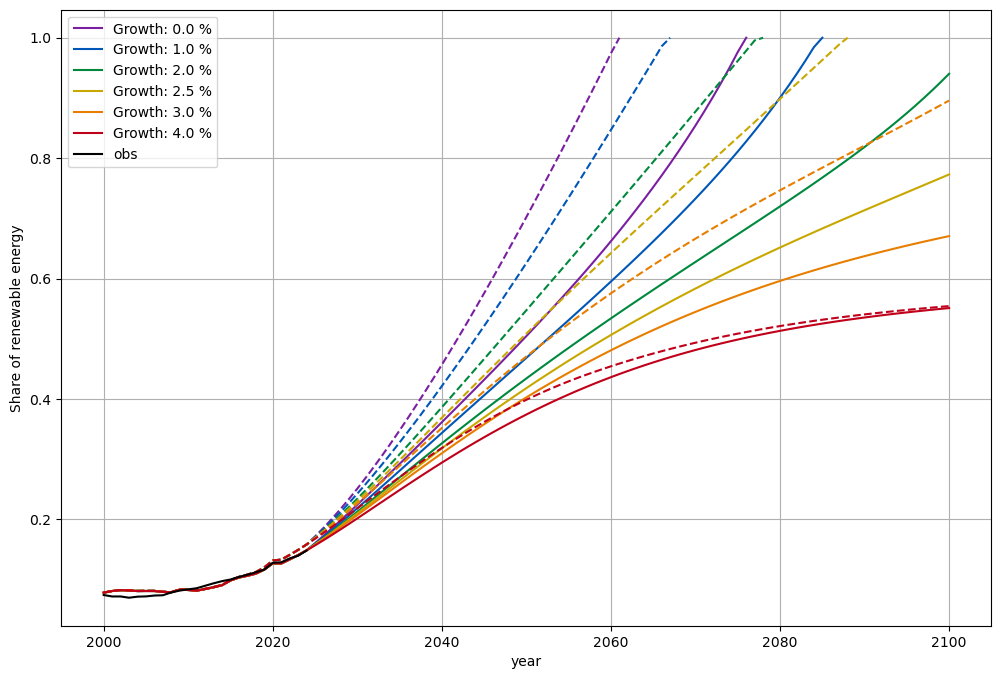

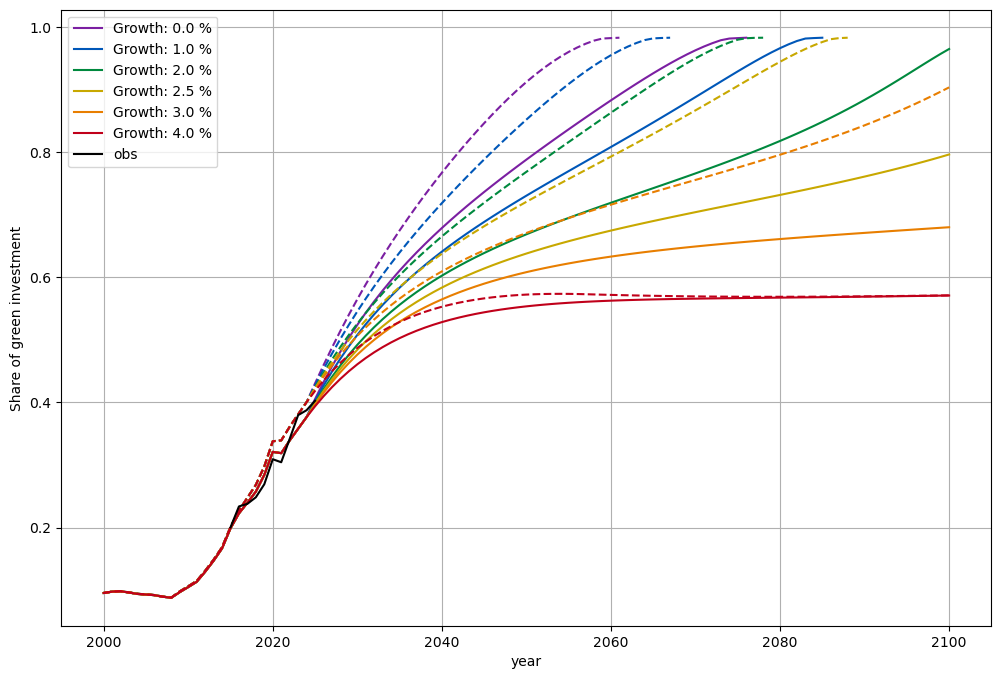

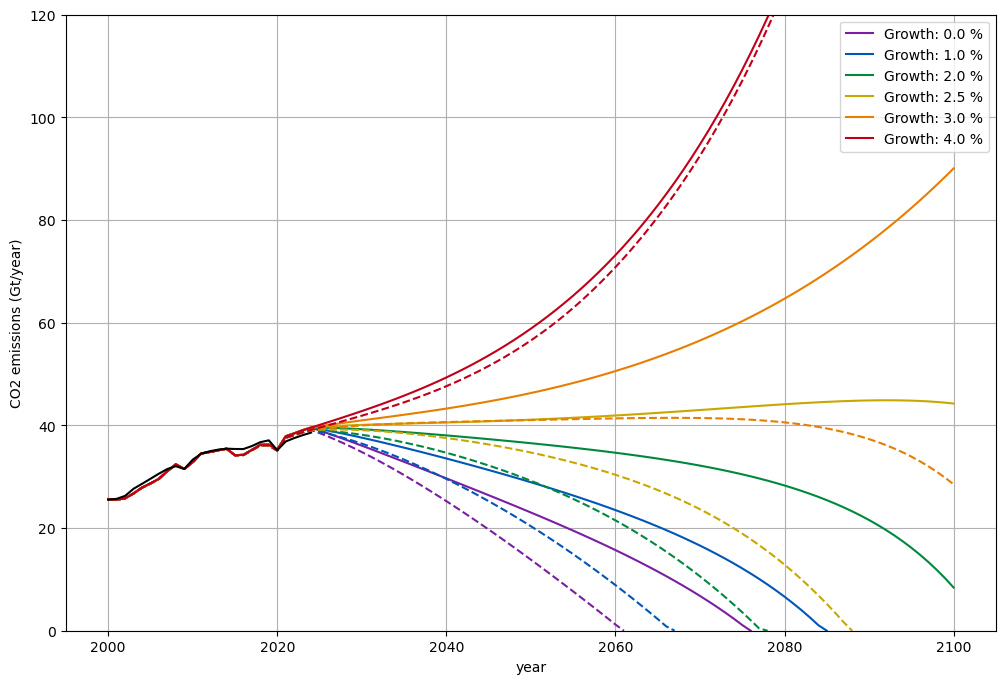

In [196]:
params_fit_minp = params_fit.copy()
params_fit_minp['min_price'] = 1.

resu_groscen_minp = []
for gro in np.arange(0., 0.055, 0.005):
    print(gro)
    scen = all_growths[gro]/all_growths[gro].sel(year = 2000)
    resuok = lef.run_model(inicond = inicond_recalc, params = params_fit_minp, n_iter = 101, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=scale_costs, gdp_type='custom', gdp_scenario=scen, energy_crisis_mode = energy_crisis_mode, dynamic_price = dynamic_price, same_price=True)
    resu_groscen_minp.append(resuok)

do_all = [1, 0, 1, 0, 1, 1, 1, 0, 1]

fig = plt.figure(figsize = (12, 8))

for gro, re, re2, col, do in zip(np.arange(0., 0.055, 0.005), resu_groscen, resu_groscen_minp, rainbow_palette_9[::-1], do_all):
    if do:
        re['Eg_ratio'].plot(label = f'Growth: {int(1000*gro)/10} %', color = col)
        re2['Eg_ratio'].plot(color = col, ls = '--')

lef.Eg_ratio.sel(year = slice(2000, None)).plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('Share of renewable energy')
plt.legend()
plt.grid()

fig.savefig(cart_figs + 'resu_groscen_Egratio_dyn_check_minprice.pdf')

# %%
fig = plt.figure(figsize = (12, 8))

for gro, re, re2, col, do in zip(np.arange(0., 0.055, 0.005), resu_groscen, resu_groscen_minp, rainbow_palette_9[::-1], do_all):
    if do: 
        re['Ig_ratio'].plot(label = f'Growth: {int(1000*gro)/10} %', color = col)
        re2['Ig_ratio'].plot(color = col, ls = '--')

obs2['Ig_ratio'].sel(year = slice(2000, None)).plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('Share of green investment')
plt.legend()
plt.grid()

fig.savefig(cart_figs + 'resu_groscen_Igratio_dyn_check_minprice.pdf')

# %%
emiss_scen = dict()

# %%
fig = plt.figure(figsize = (12, 8))

for gro, re, re2, col, do in zip(np.arange(0., 0.055, 0.005), resu_groscen, resu_groscen_minp, rainbow_palette_9[::-1], do_all):
    if do: 
        lef.to_emissions(re['Ef']).plot(label = f'Growth: {int(1000*gro)/10} %', color = col)
        emiss_scen[gro] = lef.to_emissions(re['Ef'])
        lef.to_emissions(re2['Ef']).plot(color = col, ls = '--')

# lef.to_emissions(resu_hist['Ef']).sel(year = slice(2000, 2023)).plot(color = 'grey')
lef.co2.sel(year = slice(2000, None)).plot(color = 'black')
# lef.Eg_ratio.plot(label = 'obs', color = 'black')
plt.ylim(0., 120.)

plt.xlabel('year')
plt.ylabel('CO2 emissions (Gt/year)')
plt.legend()
plt.grid()

fig.savefig(cart_figs + 'resu_groscen_CO2emiss_dyn_check_minprice.pdf')

### Compare SSP1 with baseline from Riahi et al.

In [228]:
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

In [229]:
co2_ssp = lef.read_co2_scenarios()

In [203]:
co2_ssp

<xarray.Dataset>
Dimensions:          (year: 96)
Coordinates:
  * year             (year) int64 2005 2006 2007 2008 ... 2097 2098 2099 2100
Data variables: (12/26)
    SSP1 - 1.9       (year) float64 33.17 33.63 34.1 ... -13.59 -13.96 -14.34
    SSP1 - 2.6       (year) float64 33.17 33.63 34.1 ... -8.298 -8.322 -8.347
    SSP1 - 3.4       (year) float64 33.17 33.63 34.1 ... -5.747 -6.181 -6.615
    SSP1 - 4.5       (year) float64 33.17 33.63 34.1 34.56 ... 12.32 11.7 11.08
    SSP1 - Baseline  (year) float64 33.17 33.63 34.1 34.56 ... 25.41 25.01 24.61
    SSP2 - 1.9       (year) float64 37.77 38.28 38.79 ... -12.92 -12.99 -13.05
    ...               ...
    SSP5 - 1.9       (year) float64 35.28 35.5 35.72 ... -20.96 -21.13 -21.31
    SSP5 - 2.6       (year) float64 35.23 35.45 35.67 ... -18.48 -18.73 -18.98
    SSP5 - 3.4       (year) float64 35.23 35.45 35.67 ... -12.59 -13.09 -13.6
    SSP5 - 4.5       (year) float64 35.23 35.45 35.67 ... 16.12 15.99 15.86
    SSP5 - 6.0       (year) float64 35.23 35.45 35.67 ... 41.61 41.29 40.97
    SSP5 - Baseline  (year) float64 35.28 35.5 35.72 35.93 ... 127.0 126.5 126.1

In [206]:
co2_ssp['SSP1 - 1.9']

<xarray.DataArray 'SSP1 - 1.9' (year: 96)>
array([ 33.16607422,  33.63062513,  34.09517604,  34.55972696,
        35.02427787,  35.48882878,  35.26082585,  35.03282292,
        34.80481999,  34.57681706,  34.34881413,  34.1208112 ,
        33.89280827,  33.66480534,  33.43680241,  33.20879948,
        31.68471636,  30.16063324,  28.63655011,  27.11246699,
        25.58838387,  24.06430075,  22.54021763,  21.0161345 ,
        19.49205138,  17.96796826,  16.81256605,  15.65716385,
        14.50176164,  13.34635944,  12.19095723,  11.03555503,
         9.88015282,   8.72475062,   7.56934841,   6.41394621,
         5.86935521,   5.32476422,   4.78017322,   4.23558223,
         3.69099123,   3.14640024,   2.60180924,   2.05721825,
         1.51262725,   0.96803626,   0.70623278,   0.4444293 ,
         0.18262581,  -0.07917766,  -0.34098114,  -0.60278462,
        -0.86458811,  -1.12639158,  -1.38819506,  -1.64999855,
        -1.89869107,  -2.1473836 ,  -2.39607613,  -2.64476866,
        -2.89346119,  -3.14215372,  -3.39084624,  -3.63953877,
        -3.8882313 ,  -4.13692383,  -4.46025199,  -4.78358015,
        -5.10690831,  -5.43023648,  -5.75356464,  -6.0768928 ,
        -6.40022096,  -6.72354912,  -7.04687728,  -7.37020544,
        -7.68995565,  -8.00970586,  -8.32945607,  -8.64920627,
        -8.96895648,  -9.28870669,  -9.6084569 ,  -9.92820711,
       -10.24795731, -10.56770752, -10.94497923, -11.32225094,
       -11.69952266, -12.07679437, -12.45406608, -12.83133779,
       -13.2086095 , -13.58588122, -13.96315293, -14.34042464])
Coordinates:
  * year     (year) int64 2005 2006 2007 2008 2009 ... 2096 2097 2098 2099 2100

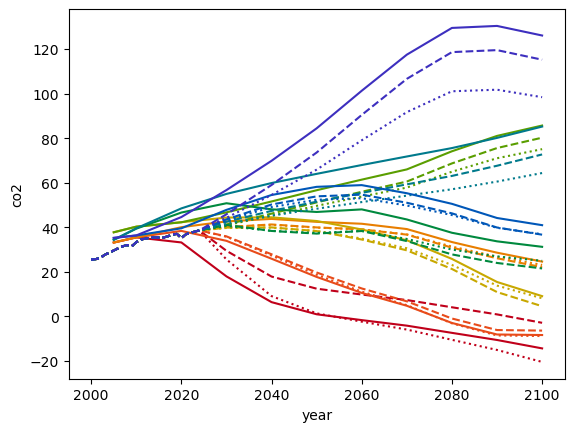

In [214]:
fig = plt.figure()
for ssp, col in zip(co2_ssp.data_vars, rainbow_palette_10):
    mismatch = co2_ssp[ssp].sel(year = 2024) - lef.co2.sel(year = 2024)
    misfact = co2_ssp[ssp].sel(year = 2024)/lef.co2.sel(year = 2024)
    co2_ssp[ssp].plot(label = ssp, color = col, ls = '-')

    fitto = xr.concat([lef.co2.sel(year = slice(2000, 2024)), co2_ssp[ssp].sel(year = slice(2025, None))-mismatch.values], dim = 'year')
    fitto.plot(label = ssp + ' (shifted)', color = col, ls = '--')

    fitto2 = xr.concat([lef.co2.sel(year = slice(2000, 2024)), co2_ssp[ssp].sel(year = slice(2025, None))/misfact.values], dim = 'year')
    fitto2.plot(label = ssp + ' (scaled)', color = col, ls = ':')

<xarray.DataArray ()>
array(0.)
Coordinates:
    year     int64 2024 <xarray.DataArray ()>
array(1.)
Coordinates:
    year     int64 2024
<xarray.DataArray ()>
array(0.)
Coordinates:
    year     int64 2024 <xarray.DataArray ()>
array(1.)
Coordinates:
    year     int64 2024
<xarray.DataArray ()>
array(0.)
Coordinates:
    year     int64 2024 <xarray.DataArray ()>
array(1.)
Coordinates:
    year     int64 2024
<xarray.DataArray ()>
array(0.)
Coordinates:
    year     int64 2024 <xarray.DataArray ()>
array(1.)
Coordinates:
    year     int64 2024
<xarray.DataArray ()>
array(0.)
Coordinates:
    year     int64 2024 <xarray.DataArray ()>
array(1.)
Coordinates:
    year     int64 2024
<xarray.DataArray ()>
array(0.)
Coordinates:
    year     int64 2024 <xarray.DataArray ()>
array(1.)
Coordinates:
    year     int64 2024
<xarray.DataArray ()>
array(0.)
Coordinates:
    year     int64 2024 <xarray.DataArray ()>
array(1.)
Coordinates:
    year     int64 2024
<xarray.DataArray ()>
array(0.)
Co

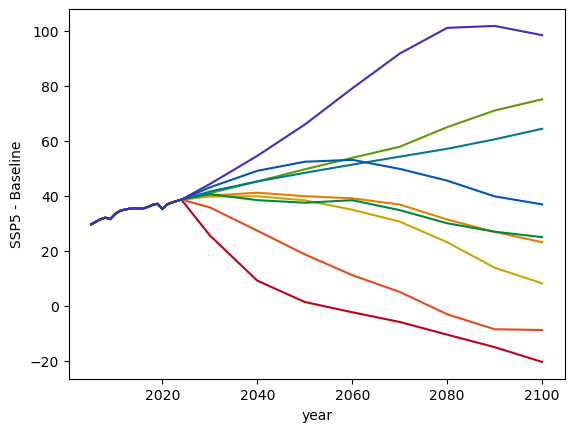

In [220]:
fig = plt.figure()
for ssp, col in zip(co2_ssp.data_vars, rainbow_palette_10):
    mismatch = co2_ssp[ssp].sel(year = 2024) - lef.co2.sel(year = 2024)
    misfact = co2_ssp[ssp].sel(year = 2024)/lef.co2.sel(year = 2024)
    print(mismatch, misfact)
    co2_ssp[ssp].plot(label = ssp, color = col, ls = '-')

In [221]:
[resu_groscen, resu_allscen] = pickle.load(open(cart_figs + f'results_{tag}.p', 'rb'))

In [223]:
resu_allscen[0]

<xarray.Dataset>
Dimensions:   (year: 93)
Coordinates:
  * year      (year) int64 2000 2001 2002 2003 2004 ... 2088 2089 2090 2091 2092
Data variables: (12/15)
    Y         (year) float64 1.0 0.9939 1.032 1.158 ... 13.79 13.92 14.03 14.14
    Kg        (year) float64 0.07613 0.07855 0.08089 ... 4.471 4.62 4.778
    Kf        (year) float64 0.9602 0.9807 0.9999 1.019 ... 2.319 2.301 2.281
    E         (year) float64 1.0 0.9982 1.009 1.046 ... 4.767 4.806 4.837 4.869
    Eg        (year) float64 0.07825 0.08074 0.08314 ... 4.596 4.749 4.869
    Ef        (year) float64 0.9217 0.9175 0.9264 0.9609 ... 0.2096 0.08816 0.0
    ...        ...
    Pg        (year) float64 0.00126 0.001255 0.001275 ... 0.614 0.6521 0.6822
    Pf        (year) float64 0.1041 0.0999 0.09975 ... 0.01208 0.001394 0.0
    Ig_ratio  (year) float64 0.09532 0.09744 0.09805 ... 0.9764 0.9827 0.9834
    Eg_ratio  (year) float64 0.07825 0.08089 0.08236 ... 0.9564 0.9818 1.0
    Cg        (year) float64 0.07043 0.07267 0.07483 ... 0.6146 0.6247 0.6326
    Cf        (year) float64 0.2752 0.2746 0.2759 0.281 ... 0.1312 0.07934 0.0
Attributes:
    success:      True
    transition:   True
    year_zero:    2092
    year_peak:    2050
    year_halved:  2083

In [230]:
baselines = co2_ssp[[ssp for ssp in co2_ssp if 'Baseline' in ssp]]

In [232]:
baselines.data_vars

Data variables:
    SSP1 - Baseline  (year) float64 29.6 30.59 31.5 32.05 ... 23.87 23.49 23.11
    SSP2 - Baseline  (year) float64 29.6 30.59 31.5 32.05 ... 74.27 74.67 75.08
    SSP3 - Baseline  (year) float64 29.6 30.59 31.5 32.05 ... 63.6 63.98 64.36
    SSP4 - Baseline  (year) float64 29.6 30.59 31.5 32.05 ... 39.23 38.99 38.75
    SSP5 - Baseline  (year) float64 29.6 30.59 31.5 32.05 ... 99.08 98.75 98.41

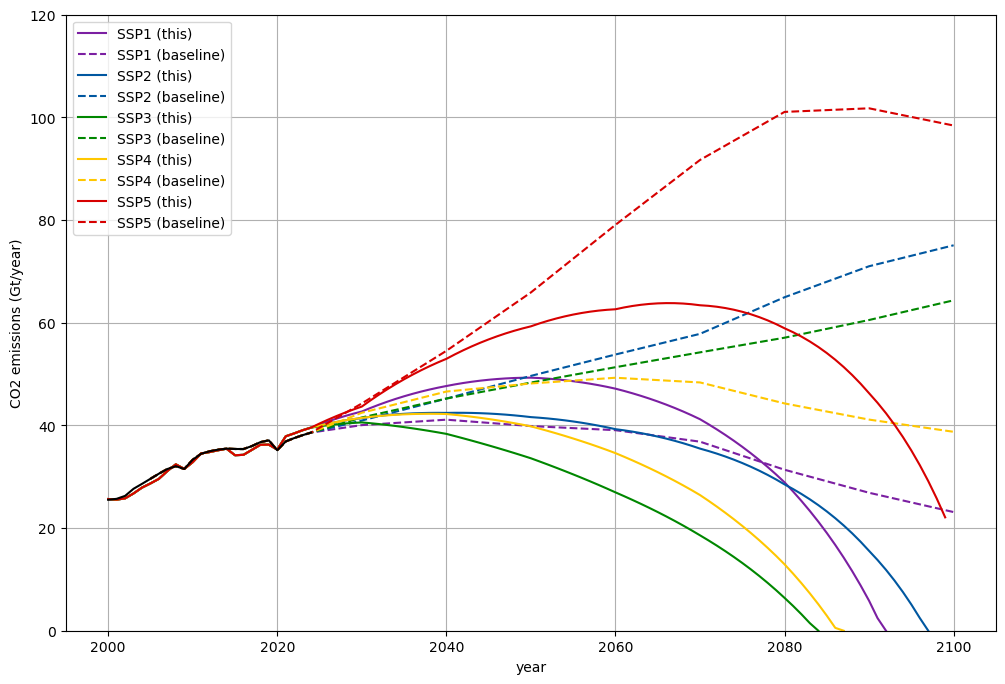

In [233]:
fig = plt.figure(figsize = (12, 8))

for ssp, re, scen, col in zip([f'SSP{i}' for i in range(1,6)], resu_allscen, baselines.data_vars, rainbow_palette_5[::-1]):
    lef.to_emissions(re['Ef']).plot(label = f'{ssp} (this)', color = col)
    baselines[scen].plot(label = f'{ssp} (baseline)', color = col, ls = '--')
    
# lef.to_emissions(resu_hist['Ef']).sel(year = slice(2000, 2023)).plot(color = 'grey')
lef.co2.sel(year = slice(2000, None)).plot(color = 'black')
# lef.Eg_ratio.plot(label = 'obs', color = 'black')
plt.ylim(0., 120.)

plt.xlabel('year')
plt.ylabel('CO2 emissions (Gt/year)')
plt.legend()
plt.grid()

fig.savefig(cart_figs + 'resu_sspscen_CO2emiss_vs_baselines.pdf')

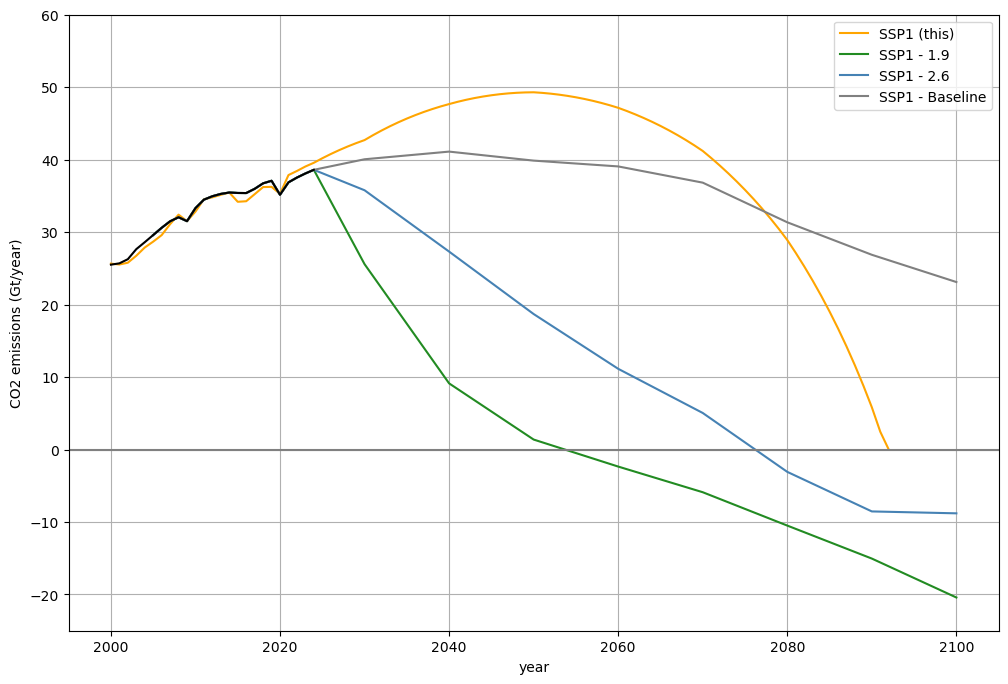

In [243]:
fig = plt.figure(figsize = (12, 8))

#for ssp, re, scen, col in zip([f'SSP{i}' for i in range(1,6)], resu_allscen, baselines.data_vars, rainbow_palette_5[::-1]):
re = resu_allscen[0]
col = rainbow_palette_5[-1]
ssp = 'SSP1'
lef.to_emissions(re['Ef']).plot(label = f'{ssp} (this)', color = 'orange')

co2_ssp['SSP1 - 1.9'].plot(label = f'{ssp} - 1.9', color = 'forestgreen')#, ls = ':')
co2_ssp['SSP1 - 2.6'].plot(label = f'{ssp} - 2.6', color = 'steelblue')#, ls = '--')
co2_ssp['SSP1 - Baseline'].plot(label = f'{ssp} - Baseline', color = 'grey')#, ls = '-.')
    
# lef.to_emissions(resu_hist['Ef']).sel(year = slice(2000, 2023)).plot(color = 'grey')
lef.co2.sel(year = slice(2000, None)).plot(color = 'black')
# lef.Eg_ratio.plot(label = 'obs', color = 'black')
plt.ylim(-25., 60.)
plt.axhline(0., color = 'grey')

plt.xlabel('year')
plt.ylabel('CO2 emissions (Gt/year)')
plt.legend()
plt.grid()

fig.savefig(cart_figs + 'resu_sspscen_CO2emiss_SSP1_vs_Riahi.pdf')